In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_pure_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [10]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# # Source parameters
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5  # Gpc
# qS = np.pi
# phiS = 0.
# qK =  0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5                                                                                                                           

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038                                                                                                                                                                                                                                                                                                                                 
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [11]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [12]:
# n-indexed mode selection parameters
n_vals = np.arange(-5,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [13]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

# no noise check

In [14]:


loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)], [(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)], [(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)], [(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)], [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)], [(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)], [(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)], [(2, 0, -2), (2, 1, -2), (2, 2, -2), (

In [15]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

rho_tot=100.687, rho_dom_M=38.1499, beta=0.000838831
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)]      29.5761      28.9497         0.392339
[(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)]      35.1566      34.4124         0.553786
[(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)]      38.8942      38.1499         0.554026
[(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)]      36.4666      35.8795         0.344729
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.3457       24.059        0.0822386
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      6.16785      6.19411      0.000689489
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.00612      4.87158        0.0181011
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]     0.313461     0.385405       0.00517583
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, 

In [16]:
params_secondary = [10**5.82595158, 10**1.99267966, 0.49587826, 15.73817815, 0.74416625, xI0, 
                dist,np.arccos(0.82400395),3.55596108, qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [36]:
h_true = gwf.xp.array(waveform_response(
    m1, m2, a, p0, e0,
    xI0, dist,qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [37]:
maxld_pt1 = [[ 5.82595158, 1.99267966, 0.49587826, 15.73817815, 0.74416625, 0.82400395, 3.55596108 ]]

In [38]:
h_pt1 = gwf.xp.array(waveform_response(
    10**maxld_pt1[0][0], 10**maxld_pt1[0][1], maxld_pt1[0][2], maxld_pt1[0][3], maxld_pt1[0][4],
    xI0, dist, np.arccos(maxld_pt1[0][5]),maxld_pt1[0][6], qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [39]:
gwf.rhostat(h_true), gwf.rhostat(h_pt1)

(array(250.13444189), array(205.67926171))

In [40]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true))/(gwf.rhostat(h_true)*gwf.rhostat(h_true))

array(1.)

In [41]:
gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1))/(gwf.rhostat(h_pt1)*gwf.rhostat(h_pt1))

array(1.)

In [42]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))/(gwf.rhostat(h_true)*gwf.rhostat(h_pt1))

array(0.37288146)

In [43]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))/np.sqrt(gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1)))

array(93.27049609)

In [44]:
np.sqrt(gwf.inner(gwf.freq_wave(h_pt1),gwf.freq_wave(h_pt1)))

array(205.67926171)

In [45]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true))/np.sqrt(gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_true)))

array(250.13444189)

In [46]:
np.sqrt(gwf.inner(gwf.freq_wave(h_pt1), gwf.freq_wave(h_pt1)))

array(205.67926171)

# apply rishav's method (aw)  from these recovered points 

In [17]:
loglike_obj(params_secondary)

rho_tot=101.432, rho_dom_M=38.6217, beta=0.000830719
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)]      29.3179      29.2586       0.00352068
[(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)]      34.9035      34.8261       0.00598069
[(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)]      38.6834      38.6217       0.00381039
[(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)]      36.2888      36.3079      0.000362635
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.1567      24.3209        0.0269868
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      6.04836      6.24197        0.0374832
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      4.85108      4.93022       0.00626231
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]     0.333394     0.379316       0.00210877
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, 

99.88140603966346

In [37]:
h_test_neg = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    mode_selection=[(2, -2, 3)], include_minus_mkn=False,
))
rho_neg2 = float(gwf.rhostat(h_test_neg))
print(f"rho for (2,-2,3) alone: {rho_neg2:.6g}")

h_test_pos = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    mode_selection=[(2, 2, 3)], include_minus_mkn=True,
))
rho_pos2 = float(gwf.rhostat(h_test_pos))
print(f"rho for (2,2,3) with include_minus_mkn=True: {rho_pos2:.6g}")

rho for (2,-2,3) alone: 0.00184496
rho for (2,2,3) with include_minus_mkn=True: 38.1311


In [23]:
amp = loglike_obj.amp   # substitute the actual variable name of your near-plunge LogLike instance if different

l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)
n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)

print(l_arr.shape, l_arr.min(), l_arr.max())

(12987,) 2 10


In [35]:
T

1.0

In [46]:
import numpy as np
from few.utils.geodesic import get_fundamental_frequencies

amp = loglike_obj.amp

_, p, e, x, _, _, _ = loglike_obj.traj(
    m1, m2, a, p0, e0, xI0,
    T=T, dt=delta_T, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
)
teuk_modes = amp(a, p, e, x)

def _get_viewing_angles(qS, phiS, qK, phiK):
    cqS, sqS = np.cos(qS), np.sin(qS)
    cphiS, sphiS = np.cos(phiS), np.sin(phiS)
    cqK, sqK = np.cos(qK), np.sin(qK)
    cphiK, sphiK = np.cos(phiK), np.sin(phiK)
    R = np.array([sqS*cphiS, sqS*sphiS, cqS])
    S = np.array([sqK*cphiK, sqK*sphiK, cqK])
    phi = -np.pi/2.0
    theta = np.arccos(-np.dot(R, S))
    return theta, phi

theta_view, phi_view = _get_viewing_angles(qS, phiS, qK, phiK)
ylms = loglike_obj.ylm_gen(amp.unique_l, amp.unique_m, theta_view, phi_view).copy()[amp.inverse_lm]

OmegaPhi, _, OmegaR = get_fundamental_frequencies(a, p, e, x)

l_arr_nm = amp.l_arr_no_mask.get() if hasattr(amp.l_arr_no_mask, 'get') else np.asarray(amp.l_arr_no_mask)
m_arr_nm = amp.m_arr_no_mask.get() if hasattr(amp.m_arr_no_mask, 'get') else np.asarray(amp.m_arr_no_mask)
n_arr_nm = amp.n_arr_no_mask.get() if hasattr(amp.n_arr_no_mask, 'get') else np.asarray(amp.n_arr_no_mask)

m0mask = amp.m_arr_no_mask != 0
m0mask_cpu = m0mask.get() if hasattr(m0mask, 'get') else m0mask

# frequencies for teuk_modes' own (positive-m / no_mask) columns
gw_freqs_pos = []
for idx in range(len(l_arr_nm)):
    mm = m_arr_nm[idx].get() if hasattr(m_arr_nm[idx], 'get') else m_arr_nm[idx]
    nn = n_arr_nm[idx].get() if hasattr(n_arr_nm[idx], 'get') else n_arr_nm[idx]
    gw_freqs_pos.append(mm * OmegaPhi + nn * OmegaR)

# mirrored -m frequencies for the m0mask-selected reconstructed columns (appended after, same order)
gw_freqs_neg = []
for idx in range(len(l_arr_nm)):
    if not m0mask_cpu[idx]:
        continue
    mm = m_arr_nm[idx].get() if hasattr(m_arr_nm[idx], 'get') else m_arr_nm[idx]
    nn = n_arr_nm[idx].get() if hasattr(n_arr_nm[idx], 'get') else n_arr_nm[idx]
    gw_freqs_neg.append(-mm * OmegaPhi + nn * OmegaR)

gw_frequencies_per_mode = gw_freqs_pos + gw_freqs_neg

total_power = gwf.calc_power(teuk_modes, ylms, m0mask, m1=m1, m2=m2, gw_freqs=gw_frequencies_per_mode)
total_power = total_power.get() if hasattr(total_power, 'get') else total_power

pos_labels = [(int(l_arr_nm[i]), int(m_arr_nm[i]), int(n_arr_nm[i])) for i in range(len(l_arr_nm))]
neg_labels = [(int(l_arr_nm[i]), -int(m_arr_nm[i]), int(n_arr_nm[i])) for i in range(len(l_arr_nm)) if m0mask_cpu[i]]
mode_labels = pos_labels + neg_labels

power_sum = float(np.sum(total_power))
per_n = {}
for (ll, mm, nn), pw in zip(mode_labels, total_power):
    if ll != 2:
        continue
    per_n[nn] = per_n.get(nn, 0.0) + float(pw)

print(f"{'n':>4} {'power %':>10}")
for n in sorted(per_n, key=lambda k: -per_n[k])[:15]:
    print(f"{n:>4} {100*per_n[n]/power_sum:>10.4f}")

   n    power %
   3    37.9680
   2    28.9167
   4    10.1171
   1     6.4969
  -1     4.1932
   5     4.0872
   6     1.9660
   0     1.3466
   7     1.0330
   8     0.5717
   9     0.3269
  10     0.1909
  11     0.1131
  12     0.0675
  -2     0.0474


In [47]:

import numpy as np

amp = loglike_obj.amp
l_arr_nm = amp.l_arr_no_mask.get() if hasattr(amp.l_arr_no_mask, 'get') else np.asarray(amp.l_arr_no_mask)
m_arr_nm = amp.m_arr_no_mask.get() if hasattr(amp.m_arr_no_mask, 'get') else np.asarray(amp.m_arr_no_mask)
n_arr_nm = amp.n_arr_no_mask.get() if hasattr(amp.n_arr_no_mask, 'get') else np.asarray(amp.n_arr_no_mask)

# take the top candidates by calc_power's own ranking (from mode_power_true.csv) so
# this stays cheap -- generating a waveform per single mode is expensive otherwise
import csv
rows = list(csv.DictReader(open(
    '/home/svu/e1498138/emri_search/work/search/paper/emri_g/mode_power_distribution_1yr/mode_power_true.csv'
)))
top_modes = [(int(r['l']), int(r['m']), int(r['n'])) for r in rows[:20] if int(r['l']) == 2]

results = []
for (ll, mm, nn) in top_modes:
    h_single = cp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        mode_selection=[(ll, mm, nn)], include_minus_mkn=False,
    ))
    rho_single = float(gwf.rhostat(h_single))
    results.append((ll, mm, nn, rho_single))

print(f"{'l':>3} {'m':>4} {'n':>4} {'rho (matched-filter)':>22}")
for ll, mm, nn, rho in sorted(results, key=lambda r: -r[3]):
    print(f"{ll:>3} {mm:>4} {nn:>4} {rho:>22.6g}")

  l    m    n   rho (matched-filter)
  2   -2   -1                107.732
  2   -2    0                91.2551
  2   -2    1                38.8858
  2   -2    2                2.81043
  2   -1    1              0.0952985
  2   -2    3              0.0526785
  2   -2    7              0.0210069
  2   -2    6              0.0206991
  2   -2    8              0.0203075
  2   -2    9              0.0188665
  2   -2    5               0.018751
  2   -2   10              0.0169414
  2   -2   11              0.0147735
  2   -2    4              0.0125846
  2   -2   12              0.0125562
  2   -1    2             0.00361197


In [48]:
for nn_test in [3, -3, -1, 1]:
    h_test = cp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        mode_selection=[(2, -2, nn_test)], include_minus_mkn=False,
    ))
    rho_test = float(gwf.rhostat(h_test))
    print(f"mode_selection=(2,-2,{nn_test}): rho = {rho_test:.6g}")

mode_selection=(2,-2,3): rho = 0.0526785
mode_selection=(2,-2,-3): rho = 60.4964
mode_selection=(2,-2,-1): rho = 107.732
mode_selection=(2,-2,1): rho = 38.8858


In [49]:
results = []
for nn in range(-12, 13):
    h_test = cp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        mode_selection=[(2, -2, nn)], include_minus_mkn=False,
    ))
    rho = float(gwf.rhostat(h_test))
    results.append((nn, rho))

print(f"{'n (mode_selection)':>20} {'rho':>12} {'power %':>10}")
tot = sum(r**2 for _, r in results)
for nn, rho in sorted(results, key=lambda r: -r[1]):
    print(f"{nn:>20} {rho:>12.6g} {100*rho**2/tot:>10.4f}")

  n (mode_selection)          rho    power %
                  -1      107.732    30.7726
                   0      91.2551    22.0793
                  -2      84.2225    18.8074
                  -3      60.4964     9.7035
                  -4      43.6817     5.0591
                   1      38.8858     4.0092
                  -5      32.5281     2.8054
                  -6      25.4651     1.7193
                  -7      21.3412     1.2076
                  -8      19.0674     0.9639
                  -9      17.7499     0.8353
                 -10      16.8053     0.7488
                 -11      15.9257     0.6725
                 -12      14.9824     0.5952
                   2      2.81043     0.0209
                   3    0.0526785     0.0000
                   7    0.0210069     0.0000
                   6    0.0206991     0.0000
                   8    0.0203075     0.0000
                   9    0.0188665     0.0000
                   5     0.018751     0.0000
          

In [27]:
n_check = [-4, -3, -2, -1, 0, 1, 2, 3, 4]  # where the blow-up concentrates

overlaps = {}
for n in n_check:
    mask2 = (l_arr == 2) & (n_arr == n)
    mask3 = (l_arr == 3) & (n_arr == n)
    group2 = [(2, int(m_arr[i]), int(n)) for i in np.where(mask2)[0]]
    group3 = [(3, int(m_arr[i]), int(n)) for i in np.where(mask3)[0]]

    h2 = cp.array(waveform_response(*params_star[:14], mode_selection=group2, include_minus_mkn=False, T=T, dt=dt))
    h3 = cp.array(waveform_response(*params_star[:14], mode_selection=group3, include_minus_mkn=False, T=T, dt=dt))

    ov = float(gwf.overlap(gwf.freq_wave(h2), gwf.freq_wave(h3)))
    overlaps[n] = ov
    print(f"n={n}: overlap(l=2, l=3) = {ov:.4f}")

n=-4: overlap(l=2, l=3) = 0.0693
n=-3: overlap(l=2, l=3) = 0.0784
n=-2: overlap(l=2, l=3) = 0.0967
n=-1: overlap(l=2, l=3) = 0.1774
n=0: overlap(l=2, l=3) = 0.0309
n=1: overlap(l=2, l=3) = 0.0135
n=2: overlap(l=2, l=3) = -0.0913
n=3: overlap(l=2, l=3) = -0.4582
n=4: overlap(l=2, l=3) = -0.4363


In [26]:
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [33]:
params_star

[672000.0,
 98.4,
 0.5,
 15.7117,
 0.744,
 1.0,
 4.755,
 0.5906,
 3.5808,
 1.1707,
 3.8495,
 3.194,
 3.378,
 0.6038]

In [34]:
from modeselectoralt import ModeSelector
from few.utils.constants import YRSID_SI

inner_gen = waveform_response.waveform_gen.waveform_generator
traj = getattr(inner_gen, 'inspiral_generator', None)
amp = getattr(inner_gen, 'amplitude_generator', None)
ylm_gen = getattr(inner_gen, 'ylm_gen', None)
delta_T = T * YRSID_SI / 5000

n_vals_l3 = np.arange(-20, 20)  # match the l=2 range you're already using here

ms = ModeSelector(params_star, traj, amp, ylm_gen, delta_T, gwf, verbose=False)
_, labels_l3 = ms.select_modes(ell=3, n_vals=n_vals_l3, M_sel=None)

current_labels = loglike_obj.selected_labels   # substitute the actual variable name of your near-plunge LogLike instance
print(len(current_labels), current_labels[:2])  # sanity check: should be the l=2 groups
# near-plunge basis (the one that produced rho_full=250.134, chi_sq(true)=1343) --
# substitute the actual variable name here
combined_labels_l23 = current_labels + labels_l3
print(f"l=2 groups: {len(current_labels)}, l=3 groups: {len(labels_l3)}, total: {len(combined_labels_l23)}")

loglike_obj_l23 = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    seed=42,
    verbose=True,
    mode_select=combined_labels_l23,
)

print("\n=== true, l=2+l=3 near-plunge basis ===")
loglike_obj_l23(params_star)

print("\n=== secondary (maxld_pt1), l=2+l=3 near-plunge basis ===")
loglike_obj_l23(theta_sec_full)


40 [[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)], [(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)]]
l=2 groups: 40, l=3 groups: 40, total: 80
Using externally provided modes: [[(2, 0, -20), (2, 1, -20), (2, 2, -20), (2, -1, -20), (2, -2, -20)], [(2, 0, -19), (2, 1, -19), (2, 2, -19), (2, -1, -19), (2, -2, -19)], [(2, 0, -18), (2, 1, -18), (2, 2, -18), (2, -1, -18), (2, -2, -18)], [(2, 0, -17), (2, 1, -17), (2, 2, -17), (2, -1, -17), (2, -2, -17)], [(2, 0, -16), (2, 1, -16), (2, 2, -16), (2, -1, -16), (2, -2, -16)], [(2, 0, -15), (2, 1, -15), (2, 2, -15), (2, -1, -15), (2, -2, -15)], [(2, 0, -14), (2, 1, -14), (2, 2, -14), (2, -1, -14), (2, -2, -14)], [(2, 0, -13), (2, 1, -13), (2, 2, -13), (2, -1, -13), (2, -2, -13)], [(2, 0, -12), (2, 1, -12), (2, 2, -12), (2, -1, -12), (2, -2, -12)], [(2, 0, -11), (2, 1, -11), (2, 2, -11), (2, -1, -11), (2, -2, -11)], [(2, 0, -10), (2, 1, -10), (2, 2, -10), (2, -1, -10), (2, -2, -10)], [(2, 0, -9), (2, 1, -9)

NameError: name 'theta_sec_full' is not defined

In [33]:
import numpy as np
import cupy as cp

# --- Build the full (unrestricted) template, same signal used everywhere else ---
m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

h_temp = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
))
h_temp_fft = gwf.freq_wave(h_temp)
rho_full = float(gwf.xp.sqrt(gwf.inner(h_temp_fft, h_temp_fft)))
print(f"rho_full = {rho_full:.6g}  (rho_full^2 = {rho_full**2:.6g})")

# --- Enumerate every (l=2, n) group (all m) present in the amp catalog, wide n range ---
amp = loglike_obj.amp
l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)
n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)

ell = 2
n_wide = np.arange(-20, 21)  # generous window; widen further if needed

records = []
for n in n_wide:
    mask = (l_arr == ell) & (n_arr == n)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        continue
    group = [(int(l_arr[i]), int(m_arr[i]), int(n)) for i in idxs]

    h_group = cp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        mode_selection=group, include_minus_mkn=False,
    ))
    h_group_fft = gwf.freq_wave(h_group)
    rho_m = float(gwf.xp.sqrt(gwf.inner(h_group_fft, h_group_fft)))

    records.append({"l": ell, "n": int(n), "n_modes": len(group), "rho_m": rho_m,
                     "power_frac_pct": 100.0 * rho_m**2 / rho_full**2})

records.sort(key=lambda r: r["power_frac_pct"], reverse=True)

sum_rho_sq = sum(r["rho_m"]**2 for r in records)
cumulative = 0.0
print(f"\nSum of per-n-group rho_m^2 / rho_full^2 = {100*sum_rho_sq/rho_full**2:.4f}%  "
      f"(sanity check -- should be close to the l>=3-loss-adjusted total if groups are ~orthogonal)\n")
print(f"{'l':>3} {'n':>4} {'#modes':>7} {'rho_m':>12} {'power %':>10} {'cum %':>10}")
for r in records:
    cumulative += r["power_frac_pct"]
    print(f"{r['l']:>3} {r['n']:>4} {r['n_modes']:>7} {r['rho_m']:>12.6g} "
          f"{r['power_frac_pct']:>10.4f} {cumulative:>10.4f}")

# --- Specifically: what the CURRENT chi_sq basis (n in n_vals) captures, match
n_vals_set = set(int(n) for n in n_vals)  # n_vals = np.arange(-1, 6) from earlier in the notebook
captured_pct = sum(r["power_frac_pct"] for r in records if r["n"] in n_vals_set)
print(f"\nMatched-filter power % captured by current n_vals={sorted(n_vals_set)} (l=2 only): {captured_pct:.4f}%")  

rho_full = 100.687  (rho_full^2 = 10137.8)

Sum of per-n-group rho_m^2 / rho_full^2 = 86.0388%  (sanity check -- should be close to the l>=3-loss-adjusted total if groups are ~orthogonal)

  l    n  #modes        rho_m    power %      cum %
  2   -3       5      38.1499    14.3563    14.3563
  2   -2       5      35.8795    12.6984    27.0547
  2   -4       5      34.4124    11.6812    38.7359
  2   -5       5      28.9497     8.2670    47.0029
  2   -6       5       24.217     5.7849    52.7878
  2   -1       5       24.059     5.7097    58.4975
  2   -7       5      20.9591     4.3331    62.8306
  2   -8       5      18.9636     3.5473    66.3779
  2   -9       5      17.7238     3.0986    69.4766
  2  -10       5      16.8017     2.7846    72.2612
  2  -11       5      15.9284     2.5026    74.7638
  2  -12       5      14.9846     2.2149    76.9787
  2  -13       5       13.946     1.9185    78.8972
  2  -14       5      12.8309     1.6239    80.5211
  2  -15       5      11.6723  

In [26]:
params

[672000.0,
 98.4,
 0.5,
 15.7117,
 0.744,
 1.0,
 4.755,
 0.5906,
 3.5808,
 1.1707,
 3.8495,
 3.194,
 3.378,
 0.6038]

In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

rho_tot=97.0008, rho_dom_M=35.9127, beta=0.000882103
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)]    -0.104151      28.8812          840.153
[(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)]      0.12213      33.5452           1117.1
[(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)]   -0.0883168      35.9127          1296.07
[(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)] -0.000299109      32.3033          1043.52
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]    0.0460848       20.539          419.961
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]   -0.0929649      4.78061          23.7517
X_scalar=0.0304647, chi_sq=4740.56, f_stat=0.00376496
Pure log-likelihood: 0.00376496
0.0037649563466237482


In [38]:
params_secondary = [10**5.82595158, 10**1.99267966, 0.49587826, 15.73817815, 0.74416625, xI0, 
                dist,np.arccos(0.82400395),3.55596108, qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [39]:
loglike_obj(params_secondary)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=856.1, rho=29.26
  Mode 1: <hf|hf>_timemax=1213, rho=34.83
  Mode 2: <hf|hf>_timemax=1492, rho=38.62
  Mode 3: <hf|hf>_timemax=1318, rho=36.31
  Mode 4: <hf|hf>_timemax=591.5, rho=24.32
  Mode 5: <hf|hf>_timemax=38.96, rho=6.242
rho_m: [29.25857216 34.82611852 38.62167306 36.30786734 24.32093919  6.24197023]
Dominant mode index: 2, rho: 38.62
beta=0.0008307, rho_dom_M=38.62, rho_tot=101.4
X_scalar (time-maximized): 99.96
Time-maximized Log-likelihood: 99.9567


99.95668194107846

In [48]:
maxld_pt1 = np.array([[ 5.82595158,  1.99267966,  0.49587826, 15.73817815,  0.74416625,  0.82400395,
   3.55596108]])


In [49]:
import numpy as np
import cupy as cp

def per_mode_leakage(theta_full, label):
    """
    theta_full: full 14-param vector [m1, m2, a, p0, e0, xI0, dist, qS, phiS,
                                       qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    Computes, for each selected mode group h_m(theta), the projection of the
    'missing' residual d_missing = d - sum_m h_m(theta) onto ĥ_m(theta) --
    i.e. the non-orthogonality between the residual and each included mode.
    """
    waveform_groups = loglike_obj._generate_selected_waveforms(
        theta_full, loglike_obj.selected_labels
    )  # (N_groups, n_chan, N)

    # sum of everything the basis currently includes, evaluated at theta
    h_included_sum = gwf.xp.sum(waveform_groups, axis=0)
    h_included_fft = gwf.freq_wave(h_included_sum)

    # residual: whatever's in d that this basis, AT THIS theta, doesn't cover
    d_missing_fft = loglike_obj.signal_fft - h_included_fft
    rho_missing = float(gwf.xp.sqrt(gwf.inner(d_missing_fft, d_missing_fft)))

    print(f"\n=== {label} ===")
    print(f"||d_missing|| = {rho_missing:.6g}  (rho_full={float(gwf.xp.sqrt(gwf.inner(loglike_obj.signal_fft, loglike_obj.signal_fft))):.6g})")
    print(f"{'group':>18} {'rho_m':>10} {'leakage=<d_missing|h_m>':>24} {'corr (orthogonality)':>22}")

    total_chi_sq = 0.0
    for i, group in enumerate(loglike_obj.selected_labels):
        h_m = waveform_groups[i]
        h_m_fft = gwf.freq_wave(h_m)
        rho_m = float(gwf.xp.sqrt(gwf.inner(h_m_fft, h_m_fft)))

        leakage = float(gwf.inner(d_missing_fft, h_m_fft, return_complex=False))  # <d_missing|h_m>
        corr = leakage / (rho_missing * rho_m) if rho_missing > 0 and rho_m > 0 else 0.0

        # this should match (X_m - rho_m) up to the small cross-group terms
        # we already showed are ~0 (orthogonal groups)
        gap = leakage / rho_m
        total_chi_sq += gap**2

        n_label = group[0][2]  # n value (same for whole group)
        print(f"n={n_label:>14} {rho_m:>10.4g} {leakage:>24.6g} {corr:>22.4f}")

    print(f"reconstructed chi_sq ~ {total_chi_sq:.6g}  (compare to logden's printed chi_sq)")


# theta_true / theta_sec as full 14-param vectors, matching params_star's ordering
theta_true_full = params  # already full 14-param

logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

per_mode_leakage(theta_true_full, "theta_true")
per_mode_leakage(theta_sec_full, "theta_sec (maxld_pt1)")


=== theta_true ===
||d_missing|| = 107.455  (rho_full=250.134)
             group      rho_m  leakage=<d_missing|h_m>   corr (orthogonality)
n=           -20      6.353                  1.99312                 0.0029
n=           -19      7.282                  8.61648                 0.0110
n=           -18      8.294                  10.6182                 0.0119
n=           -17      9.376                   5.9509                 0.0059
n=           -16      10.51                 -2.15535                -0.0019
n=           -15      11.68                 -7.19151                -0.0057
n=           -14      12.84                 -4.53338                -0.0033
n=           -13      13.95                   4.4439                 0.0030
n=           -12      14.99                  13.1412                 0.0082
n=           -11      15.93                  15.1578                 0.0089
n=           -10      16.81                  9.75091                 0.0054
n=            -9      

In [4]:
import sys
import few
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
import numpy as np 

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 12/12
dt = 5

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)


# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038  

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing loglike_tm...
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5

In [5]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=578.8, rho=24.06
  Mode 1: <hf|hf>_timemax=38.37, rho=6.194
  Mode 2: <hf|hf>_timemax=23.73, rho=4.872
  Mode 3: <hf|hf>_timemax=0.1485, rho=0.3854
  Mode 4: <hf|hf>_timemax=0.1588, rho=0.3985
  Mode 5: <hf|hf>_timemax=0.1282, rho=0.358
  Mode 6: <hf|hf>_timemax=0.09078, rho=0.3013
rho_m: [24.05897731  6.19411006  4.87158379  0.3854046   0.39849474  0.35804469
  0.30130288]
Dominant mode index: 0, rho: 24.06
beta=0.0006655, rho_dom_M=24.06, rho_tot=100.7
X_scalar (time-maximized): 100.7
Time-maximized Log-likelihood: 100.679
100.67886784757164 100.6488511681253 100.64885116811176


(None, 100.67886784757167)

In [6]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.000117, rho=0.01082
  Mode 1: <hf|hf>_timemax=0.001698, rho=0.0412
  Mode 2: <hf|hf>_timemax=0.0004737, rho=0.02176
  Mode 3: <hf|hf>_timemax=4.496e-06, rho=0.00212
  Mode 4: <hf|hf>_timemax=1.558e-05, rho=0.003947
  Mode 5: <hf|hf>_timemax=3.55e-05, rho=0.005959
  Mode 6: <hf|hf>_timemax=6.655e-05, rho=0.008158
rho_m: [0.01081521 0.041203   0.02176391 0.00212048 0.00394745 0.00595851
 0.00815802]
Dominant mode index: 1, rho: 0.0412
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.000117, rho=0.01082
  Mode 1: <hf|hf>_timemax=0.001698, rho=0.04121
  Mode 2: <hf|hf>_timemax=0.0004738, rho=0.02177
  Mode 3: <hf|hf>_timemax=4.497e-06, rho=0.002121
  Mode 4: <hf|hf>_timemax=1.559e-05, rho=0.003948
  Mode 5: <hf|hf>_timemax=3.551e-05, rho=0.005959
  Mode 6: <hf|hf>_timemax=6.658e-05, rho=0.00816
rho_m: [0.01081661 0.04120739 0.02176687 0.00212072 0.00394796 0.00595941
 0.00815988]
Dominant mode index: 1, rho:

In [7]:
import matplotlib.pyplot as plt

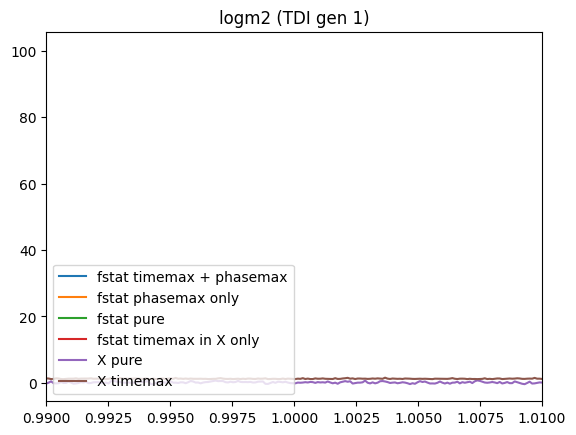

In [8]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

In [22]:
import numpy as np
import cupy as cp

m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

# --- 1. Full, unrestricted template (what X_scalar / rho_tot actually see) ---
h_temp = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
))
rho_full = gwf.rhostat(h_temp)
print(f"rho_full (all l, all n) = {float(rho_full):.6g}")

# --- 2. All (l=2, m, n) triples the amplitude model actually has, no n restriction ---
amp = loglike_obj.amp
l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)
n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)

mask_l2 = (l_arr == 2)
all_l2_modes = [(2, int(m_arr[i]), int(n_arr[i])) for i in np.where(mask_l2)[0]]
print(f"Number of (l=2, m, n) modes available: {len(all_l2_modes)}")
print(f"n range present at l=2: {sorted(set(n for _,_,n in all_l2_modes))}")

# --- 3. Full l=2 waveform (ALL n, not just n_vals=[-1..5]) ---
h_l2_full = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    mode_selection=all_l2_modes,
    include_minus_mkn=False,
))
rho_l2_full = gwf.rhostat(h_l2_full)
overlap_l2_full = gwf.overlap(gwf.freq_wave(h_temp), gwf.freq_wave(h_l2_full))
print(f"rho_l2_full (l=2, all n)     = {float(rho_l2_full):.6g}")
print(f"rho_l2_full / rho_full       = {float(rho_l2_full/rho_full):.6g}")
print(f"overlap(h_temp, h_l2_full)   = {float(overlap_l2_full):.6g}")

# --- 4. What the CURRENT chi_sq basis actually covers: l=2, n in n_vals only ---
n_vals_set = set(int(n) for n in n_vals)  # n_vals = np.arange(-1, 6) from the notebook
restricted_l2_modes = [(l, mm, n) for (l, mm, n) in all_l2_modes if n in n_vals_set]
print(f"Number of (l=2, m, n) modes in current chi_sq basis (n in {sorted(n_vals_set)}): {len(restricted_l2_modes)}")

h_l2_restricted = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    mode_selection=restricted_l2_modes,
    include_minus_mkn=False,
))
rho_l2_restricted = gwf.rhostat(h_l2_restricted)
overlap_l2_restricted = gwf.overlap(gwf.freq_wave(h_temp), gwf.freq_wave(h_l2_restricted))
print(f"rho_l2_restricted (n in n_vals)   = {float(rho_l2_restricted):.6g}")
print(f"rho_l2_restricted / rho_full      = {float(rho_l2_restricted/rho_full):.6g}")
print(f"overlap(h_temp, h_l2_restricted)  = {float(overlap_l2_restricted):.6g}")


(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


rho_full (all l, all n) = 100.687
Number of (l=2, m, n) modes available: 555
n range present at l=2: [-55, -54, -53, -52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]
rho_l2_full (l=2, all n)     = 93.9794
rho_l2_full / rho_full       = 0.933385
overlap(h_temp, h_l2_full)   = 0.951543
Number of (l=2, m, n) modes in current chi_sq basis (n in [-1, 0, 1, 2, 3, 4, 5]): 35
rho_l2_restricted (n in n_vals)   = 73.4373
rho_l2_restricted / rho_full      = 0.729365
overlap(h_temp, h_l2_restricted)  = 0.741193


In [23]:
print("\n--- Summary ---")
print(f"Power fraction lost to l>=3:            {1 - float(rho_l2_full/rho_full)**2:.4%}")
print(f"Additional power fraction lost to n outside n_vals: "
      f"{float(rho_l2_full/rho_full)**2 - float(rho_l2_restricted/rho_full)**2:.4%}")


--- Summary ---
Power fraction lost to l>=3:            12.8792%
Additional power fraction lost to n outside n_vals: 33.9234%


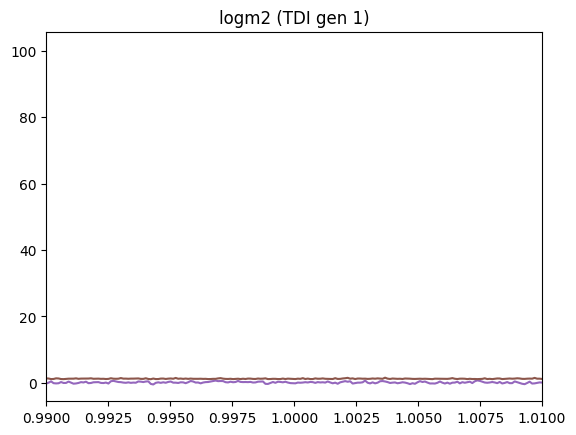

In [9]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()

# check with noise/

In [ ]:


loglike_obj_noise = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

In [ ]:
#loglike at true param
logl_true_noise=loglike_obj_noise(params)
print(logl_true_noise)

In [ ]:
                                                                                                                                                                                       
logl_perturbed_noise = loglike_obj_noise(params_perturbed)                                                                                                                                                                               
print(logl_perturbed_noise)

# 1 yr with noise

In [ ]:
gwf_1yr=GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_1yr = build_waveform_response(T=1, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_1yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_1yr,                                                                                                                                                                            
    gwf=gwf_1yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

In [ ]:
#loglike at true param
logl_1yr=loglike_1yr(params)
print(logl_1yr)

# check orthogonality

In [21]:
waveforms_per_group = []

# POSITIVE
groups = [
    [(2,-2,-1),(2,-1,-1),(2,0,-1),(2,1,-1),(2,2,-1)],   #0
    [(2,-2,0), (2,-1,0), (2,0,0), (2,1,0), (2,2,0)],    #1
    [(2,-2,1), (2,-1,1), (2,0,1), (2,1,1), (2,2,1)],    #2
    [(2,-2,2), (2,-1,2), (2,0,2), (2,1,2), (2,2,2)],    #3
    [(2,-2,3), (2,-1,3), (2,0,3), (2,1,3), (2,2,3)],    #4
    [(2,-2,4), (2,-1,4), (2,0,4), (2,1,4), (2,2,4)],    #5
    [(2,-2,5), (2,-1,5), (2,0,5), (2,1,5), (2,2,5)],    #6
    [(3,-3,-1),(3,-2,-1),(3,-1,-1),(3,0,-1),(3,1,-1),(3,2,-1),(3,3,-1)],  #7
    [(3,-3,0), (3,-2,0), (3,-1,0), (3,0,0), (3,1,0), (3,2,0), (3,3,0)],   #8
    [(3,-3,1), (3,-2,1), (3,-1,1), (3,0,1), (3,1,1), (3,2,1), (3,3,1)],   #9
    [(3,-3,2), (3,-2,2), (3,-1,2), (3,0,2), (3,1,2), (3,2,2), (3,3,2)],   #10
    [(3,-3,3), (3,-2,3), (3,-1,3), (3,0,3), (3,1,3), (3,2,3), (3,3,3)],   #11
    [(3,-3,4), (3,-2,4), (3,-1,4), (3,0,4), (3,1,4), (3,2,4), (3,3,4)],   #12
    [(3,-3,5), (3,-2,5), (3,-1,5), (3,0,5), (3,1,5), (3,2,5), (3,3,5)],   #13
]

#NEGATVIVE
# groups = [
#     [(2,-2,-5),(2,-1,-5),(2,0,-5),(2,1,-5),(2,2,-5)],   #0
#     [(2,-2,-4),(2,-1,-4),(2,0,-4),(2,1,-4),(2,2,-4)],   #1
#     [(2,-2,-3),(2,-1,-3),(2,0,-3),(2,1,-3),(2,2,-3)],   #2
#     [(2,-2,-2),(2,-1,-2),(2,0,-2),(2,1,-2),(2,2,-2)],   #3
#     [(2,-2,-1),(2,-1,-1),(2,0,-1),(2,1,-1),(2,2,-1)],   #4
#     [(2,-2,0), (2,-1,0), (2,0,0), (2,1,0), (2,2,0)],    #5
#     [(2,-2,1), (2,-1,1), (2,0,1), (2,1,1), (2,2,1)],    #6
#     [(3,-3,-5),(3,-2,-5),(3,-1,-5),(3,0,-5),(3,1,-5),(3,2,-5),(3,3,-5)],  #7
#     [(3,-3,-4),(3,-2,-4),(3,-1,-4),(3,0,-4),(3,1,-4),(3,2,-4),(3,3,-4)],  #8
#     [(3,-3,-3),(3,-2,-3),(3,-1,-3),(3,0,-3),(3,1,-3),(3,2,-3),(3,3,-3)],  #9
#     [(3,-3,-2),(3,-2,-2),(3,-1,-2),(3,0,-2),(3,1,-2),(3,2,-2),(3,3,-2)],  #10
#     [(3,-3,-1),(3,-2,-1),(3,-1,-1),(3,0,-1),(3,1,-1),(3,2,-1),(3,3,-1)],  #11
#     [(3,-3,0), (3,-2,0), (3,-1,0), (3,0,0), (3,1,0), (3,2,0), (3,3,0)],   #12
#     [(3,-3,1), (3,-2,1), (3,-1,1), (3,0,1), (3,1,1), (3,2,1), (3,3,1)],   #13
# ]
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [22]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

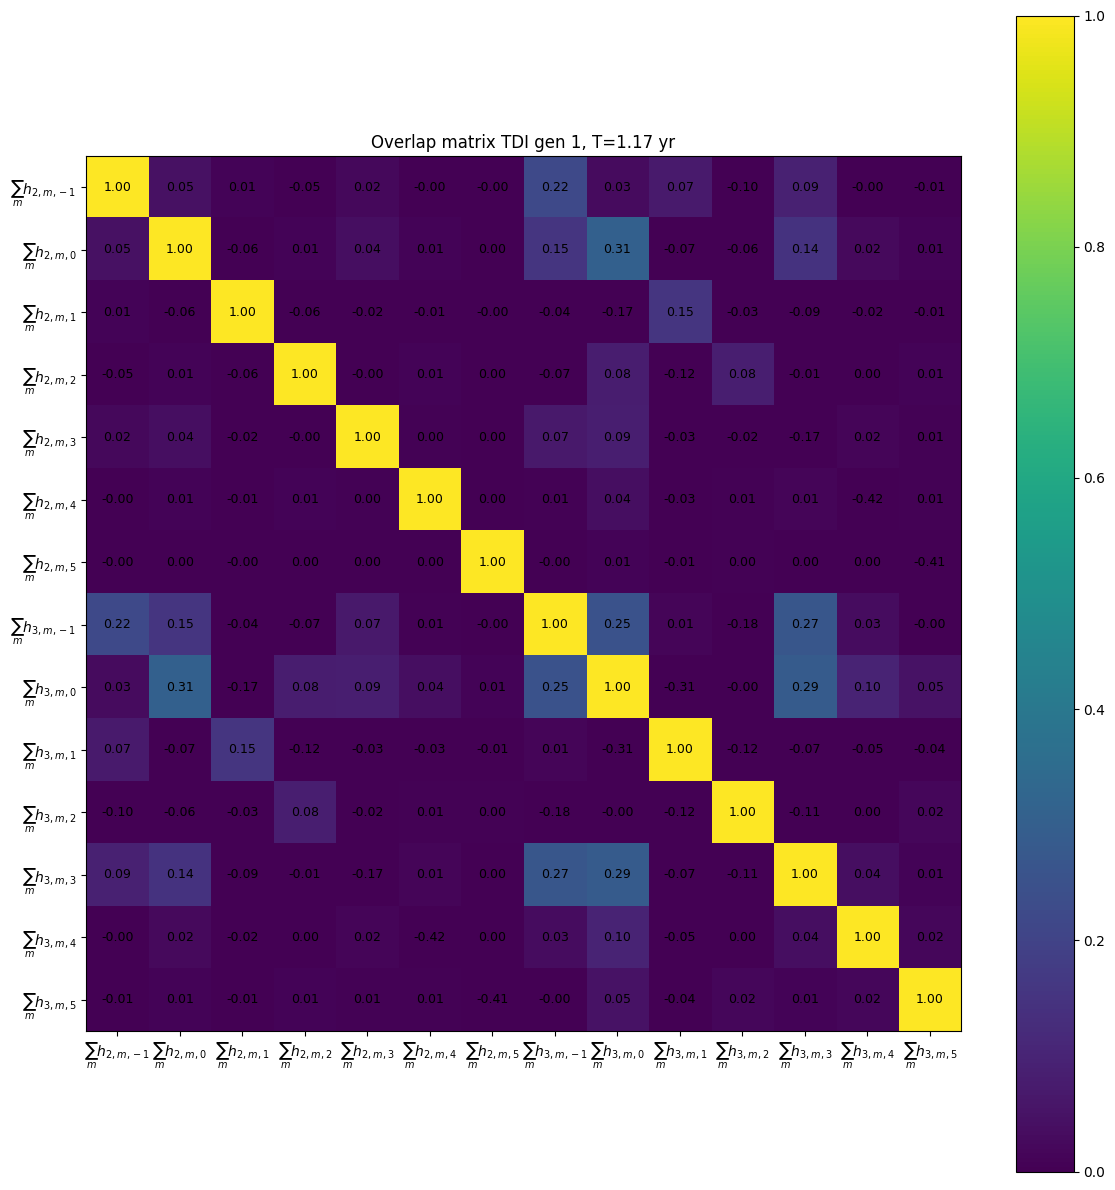

In [23]:
# Display as heatmap
# POSITIVE
labels = [
    r'$\sum_m h_{2,m,-1}$',
    r'$\sum_m h_{2,m,0}$',
    r'$\sum_m h_{2,m,1}$',
    r'$\sum_m h_{2,m,2}$',
    r'$\sum_m h_{2,m,3}$',
    r'$\sum_m h_{2,m,4}$',
    r'$\sum_m h_{2,m,5}$',
    r'$\sum_m h_{3,m,-1}$',
    r'$\sum_m h_{3,m,0}$',
    r'$\sum_m h_{3,m,1}$',
    r'$\sum_m h_{3,m,2}$',
    r'$\sum_m h_{3,m,3}$',
    r'$\sum_m h_{3,m,4}$',
    r'$\sum_m h_{3,m,5}$',
]
# labels = [
#     r'$\sum_m h_{2,m,-5}$',
#     r'$\sum_m h_{2,m,-4}$',
#     r'$\sum_m h_{2,m,-3}$',
#     r'$\sum_m h_{2,m,-2}$',
#     r'$\sum_m h_{2,m,-1}$',
#     r'$\sum_m h_{2,m,0}$',
#     r'$\sum_m h_{2,m,1}$',
#     r'$\sum_m h_{3,m,-5}$',
#     r'$\sum_m h_{3,m,-4}$',
#     r'$\sum_m h_{3,m,-3}$',
#     r'$\sum_m h_{3,m,-2}$',
#     r'$\sum_m h_{3,m,-1}$',
#     r'$\sum_m h_{3,m,0}$',
#     r'$\sum_m h_{3,m,1}$',
# ]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 1, T={:.2f} yr'.format(T))                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [20]:
overlap_matrix

array([[ 1.00000000e+00,  4.59512073e-02,  1.15039672e-02,
        -5.29717128e-02,  1.99222853e-02, -3.36389490e-03,
        -3.05622179e-03,  2.20099510e-01,  2.79541017e-02,
         7.36151552e-02, -1.00926365e-01,  9.04259911e-02,
        -7.37134208e-04, -1.01264927e-02],
       [ 4.59512073e-02,  1.00000000e+00, -5.60707750e-02,
         8.92457423e-03,  3.78888299e-02,  9.31014866e-03,
         8.80135318e-04,  1.54917682e-01,  3.05758042e-01,
        -6.89774438e-02, -6.31056839e-02,  1.44892700e-01,
         2.36850252e-02,  7.91512025e-03],
       [ 1.15039672e-02, -5.60707750e-02,  1.00000000e+00,
        -5.58263972e-02, -2.05472688e-02, -1.10113792e-02,
        -3.03189933e-03, -3.93373566e-02, -1.66909723e-01,
         1.52374998e-01, -3.40839497e-02, -8.98554214e-02,
        -1.78747644e-02, -1.33667940e-02],
       [-5.29717128e-02,  8.92457423e-03, -5.58263972e-02,
         1.00000000e+00, -1.09031588e-03,  7.90237135e-03,
         3.60427812e-03, -6.64375814e-02,  8.

# conditionals 3 mth

In [ ]:
  import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [ ]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

In [ ]:
param_true

In [ ]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

In [ ]:
def get_separatrix(a, e0):
    from few.utils.geodesic import get_separatrix
    return get_separatrix(a, e0, 1.0)  # xI=1 (prograde)

In [ ]:
get_separatrix(0.335, 0.347)

In [ ]:
f_stats_tmX

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()